In [120]:
import pyscf
import numpy as np
import scipy as sp
from pyscf import scf

def tduhf_hermitian(mf, tda=False):
    # we do uhf as the more general case
    nocc = mf.mol.nelec[0] + mf.mol.nelec[1]
    nso = 2 * mf.mol.nao
    nvirt = nso - nocc

    nalpha = mf.mol.nelec[0]
    nbeta = mf.mol.nelec[1]

    nao = mf.mol.nao

    idx_occ_a = np.arange(0, nalpha)
    idx_occ_b = np.arange(nao, nao+nbeta)

    idx_occ = np.concatenate([idx_occ_a, idx_occ_b])

    idx_all = np.arange(nso)
    idx_virt = np.setdiff1d(idx_all,idx_occ, assume_unique=True)
    perm = np.concatenate([idx_occ,idx_virt])
    

    mo_coeffs = np.zeros((nso,nso))

    alphamo = mf.mo_coeff[0]
    betamo = mf.mo_coeff[1]

    mo_coeffs[:nao,:nao] = alphamo
    mo_coeffs[nao:,nao:] = betamo

    mo_coeffs_sorted = mo_coeffs[np.ix_(perm,perm)]

    h1e = np.zeros((nso,nso))
    h1e[:nao,:nao] = np.einsum('ij,ia,jb->ab', mf.get_hcore(),alphamo, alphamo)
    h1e[nao:,nao:] = np.einsum('ij,ia,jb->ab', mf.get_hcore(),betamo, betamo)

    h1e_sorted = h1e[np.ix_(perm,perm)]

    h2e_ao = mf.mol.intor('int2e', aosym = "s1")

    h2e = np.zeros((nso,nso,nso,nso))
    h2e[:nao,:nao,:nao,:nao] = np.einsum('ijkl,ia,jb,kc,ld->abcd', h2e_ao, alphamo, alphamo, alphamo, alphamo)
    h2e[nao:,nao:,nao:,nao:] = np.einsum('ijkl,ia,jb,kc,ld->abcd', h2e_ao, betamo, betamo, betamo, betamo)
    h2e[nao:,nao:,:nao,:nao] = np.einsum('ijkl,ia,jb,kc,ld->abcd', h2e_ao, betamo, betamo, alphamo, alphamo)
    h2e[:nao,:nao,nao:,nao:] = np.einsum('ijkl,ia,jb,kc,ld->abcd', h2e_ao, alphamo, alphamo, betamo, betamo)

    h2e_sorted = h2e[np.ix_(perm,perm,perm,perm)]

    en_a = mf.mo_energy[0]
    en_b = mf.mo_energy[1]

    energies = np.concatenate([en_a,en_b])
    energies_sorted = energies[np.ix_(perm)]


    # first define A
    A = np.zeros((nocc, nvirt, nocc, nvirt))
    A += np.einsum('ij, ab, a->iajb', np.eye(nocc), np.eye(nvirt), energies_sorted[nocc:])
    A -= np.einsum('ij, ab, i->iajb', np.eye(nocc), np.eye(nvirt), energies_sorted[:nocc])
    A += h2e_sorted[:nocc,nocc:,:nocc,nocc:] - h2e_sorted[nocc:,nocc:,:nocc,:nocc].transpose(2, 0, 3, 1)

    # print(A)

    # now define B
    B = np.zeros((nocc, nvirt, nocc, nvirt))
    if not tda:
        B += h2e_sorted[:nocc,nocc:,:nocc,nocc:] - h2e_sorted[nocc:,:nocc, :nocc, nocc:].transpose(2, 0, 1, 3)


    A_reshaped = np.reshape(A, (nocc*nvirt, nocc*nvirt))
    B_reshaped = np.reshape(B, (nocc*nvirt, nocc*nvirt))

    matrix_ABBA = np.zeros((2*nocc*nvirt, 2*nocc*nvirt))
    matrix_ABBA[:(nocc*nvirt), :(nocc*nvirt)] = A_reshaped
    matrix_ABBA[(nocc*nvirt):, (nocc*nvirt):] = A_reshaped
    matrix_ABBA[:(nocc*nvirt), (nocc*nvirt):] = B_reshaped
    matrix_ABBA[(nocc*nvirt):, :(nocc*nvirt)] = B_reshaped

    pencil = np.zeros_like(matrix_ABBA)
    pencil[:(nocc*nvirt), :(nocc*nvirt)] = np.eye(nocc*nvirt)
    pencil[(nocc*nvirt):,(nocc*nvirt):] = - np.eye(nocc*nvirt)

    eigvals, eigvecs = sp.linalg.eig(matrix_ABBA, pencil)

    # print(eigvals*27.211386245988)
    scaled_eigvals = 27.211386245988*eigvals
    # real_eigvals = []
    # for val in scaled_eigvals:
    #     if val > 0:
    #         real_eigvals.append(val)
    

    real_eigvals = []
    threshold = 1e-5  # You can adjust this for tighter/looser duplicate tolerance

    for i in range(len(scaled_eigvals)):
        thisvec = eigvecs[:,i]
        val = scaled_eigvals[i]
        if np.isreal(val) and val.real > 0 and np.linalg.norm(thisvec[:(nocc*nvirt)]) > 0.95:
            already_present = any(np.isclose(val.real, existing_val, atol=threshold) for existing_val in real_eigvals)
            if not already_present:
                real_eigvals.append(val.real)


    print("Eigenvalues in eV:")
    print(real_eigvals)


    return real_eigvals, eigvals, eigvecs

In [101]:
import numpy as np
import scipy as sp
import pyscf
from pyscf import gto, scf

mol = gto.Mole()
mol.atom = """
H    0.0    0.0    0.0
H    1.0    0.0    0.0
H    0.5    0.866    0.0
"""
mol.basis = '6-31g'
mol.charge = 0
mol.spin = 3
mol.build()

In [102]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -1.17933791723798  <S^2> = 3.75  2S+1 = 4


-1.1793379172379783

In [46]:
mf.mol.nelec

(3, 0)

In [122]:
# tduhf_res = tduhf_hermitian(mf, True)
tduhf_res_noTDA = tduhf_hermitian(mf)

Eigenvalues in eV:
[34.51653117779992, 39.89775129619074, 24.710525158065114, 17.90829122622207, 24.421775608043113, 25.162004655911257, 17.90863123371548, 2.3139733125688886e-05, 37.481753494237246, 8.417686377984126, 25.60754131967948, 44.35480720871686, 5.075975404064168, 6.937156410471391, 29.319522843671376, 31.46776455684361, 19.841333174716183, 5.075902829875249, 21.212203650575926]


In [84]:
mf.mol.nao

6

In [85]:
mf.mol.nelec

(3, 0)

34.5165311778
39.89775129619086
24.710525158065156
17.908291226222094
17.908631233715425
25.162004655911296
24.42177560804321
2.313973312008559e-05
37.48175349423726
8.417686377984111
44.35480720871694
25.60754131967954
5.075975404064175
6.9371564104713865
29.319522843671425
31.46776455684361
5.075902829875277
19.841333174716187
21.212203650575958
8.605595618279075
8.605351523264272


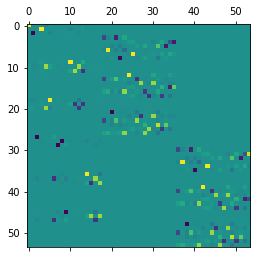

In [99]:
realeig = tduhf_res_noTDA[0]
eigvals = tduhf_res_noTDA[1]
eigvecs = tduhf_res_noTDA[2]
# print(eigvecs)

import matplotlib.pyplot as plt

plt.matshow(eigvecs)

# for i in range(len(eigvals)):
#     if np.linalg.norm(eigvecs[27:,i]) < 1e-6:
#         print(i)
#         print(eigvals[i])

# for i in range(len(eigvals)):
#     if np.linalg.norm(eigvecs[:27,i]) > 0.9:
#         print(i)
#         print(np.linalg.norm(eigvecs[:27,i]))
#         print(eigvals[i]*27.211386245988)

for j in realeig:
    if j > 0:
        print(j)

In [98]:
from pyscf import tdscf

tmf = tdscf.TDHF(mf)
tmf.singlet = False
tmf.nroots = 28
tmf.kernel()
tmf.analyze()

Excited State energies (eV)
[17.90829108 17.90863108 24.42165937 24.42177541 24.71052495 25.16200445
 34.51653089 39.8975123  39.89775096]

** Excitation energies and oscillator strengths **
Excited State   1:     17.90829 eV     69.23 nm  f=0.2435
Excited State   2:     17.90863 eV     69.23 nm  f=0.2435
Excited State   3:     24.42166 eV     50.77 nm  f=0.0120
Excited State   4:     24.42178 eV     50.77 nm  f=0.0121
Excited State   5:     24.71052 eV     50.17 nm  f=0.0000
Excited State   6:     25.16200 eV     49.27 nm  f=0.0000
Excited State   7:     34.51653 eV     35.92 nm  f=0.0000
Excited State   8:     39.89751 eV     31.08 nm  f=0.0008
Excited State   9:     39.89775 eV     31.08 nm  f=0.0008
